In [52]:
###############################################################################
# CHAPTER 5: FORECASTING PRINCIPLES & PRACTICE — PYTHON (COMPLETE SCRIPT)
###############################################################################

# =========================
# 0. INSTALL DEPENDENCIES
# =========================
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn statsforecast utilsforecast fpppy ipywidgets openpyxl 
!{sys.executable} -m pip install statsforecast --only-binary=:all:

In [54]:

# =========================
# 1. GLOBAL SETTINGS
# =========================
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})

# =========================
# 2. PLOTTING STYLE 
# =========================

import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="all_black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1804989911.py:48: UserWarning: Overwriting the cmap 'black_and_blue' that was already in the registry.
  mpl.colormaps.register(
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1804989911.py:53: UserWarning: Overwriting the cmap 'all_black' that was already in the registry.
  mpl.colormaps.register(
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1804989911.py:58: UserWarning: Overwriting the cmap 'black_and_4color' that was already in the registry.
  mpl.colormaps.register(
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1804989911.py:65: UserWarning: Overwriting the cmap 'black_and_3color' that was already in the registry.
  mpl.colormaps.register(
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1804989911.py:72: UserWarning: Overwriting the cmap 'r_colors' that was already in the registry.
  mpl.colormaps.register(


In [56]:
from itertools import combinations
from functools import partial
from typing import Optional

import sys
!{sys.executable} -m pip install mlforecast

from mlforecast import MLForecast
from mlforecast.target_transforms import GlobalSklearnTransformer
from mlforecast.utils import PredictionIntervals
from scipy import stats
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from sklearn.preprocessing import FunctionTransformer
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.feature_engineering import fourier, pipeline, trend

from fpppy.models import LinearRegression


mpl.rcParams['axes.prop_cycle'] = cycler(color=["#569CC6", "#D55F03", "#13A076"])

def plot_diagnostics(
    forecaster,
    model: Optional[str] = None,
    n_lags: int = None,
    target_col: str = "y",
    time_col: str = "ds",
):
    # Plot first model only if no model spec is given
    if model is None:
        model = list(forecaster.models.keys())[0]
    fitted = forecaster.forecast_fitted_values().assign(
        resid=lambda x: x[target_col] - x[model]
    )

    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])

    ax = axes["resid"]
    ax.plot(fitted[time_col], fitted["resid"], marker='.')
    ax.set(title="Innovation Residuals")

    ax = axes["acf"]
    plot_acf(
        fitted["resid"], ax=ax, zero=False, lags=n_lags,
        bartlett_confint=False, auto_ylims=True)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel='acf')

    ax = axes["hist"]
    ax.hist(fitted["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

def adj_r2_score(y, y_hat, T, k):
    r2 = r2_score(y, y_hat)
    return 1 - (1 - r2) * (T - 1) / (T - k - 1)

def aic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + 2 * (k + 2)

def aicc_score(y, y_hat, T, k):b
    aic = aic_score(y, y_hat, T, k)
    return aic + (2 * (k + 2) * (k + 3)) / (T - k - 3)

def bic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + (k + 2) * np.log(T)

def cv_score(mf, model='LinearRegression'):
    fitted_model = mf.models_[model]
    X = fitted_model._X_design  
    y = fitted_model._y
    e = fitted_model._residuals
    XtX_inv = np.linalg.pinv(X.T @ X)
    h = np.sum((X @ XtX_inv) * X, axis=1) 
    return np.nanmean((e / (1 - h))**2)

IndentationError: unexpected indent (3027271112.py, line 63)

In [90]:
import numpy as np
from scipy import stats

def print_regression_summary_from_mlforecast(mf, model_name):
    # actual y and fitted values
    fitted_df = mf.forecast_fitted_values()
    y = fitted_df["y"].values
    y_hat = fitted_df[model_name].values
    residuals = y - y_hat

    # rebuild X from stored features
    X = mf._fit_X[model_name]
    var_names = mf._fit_features[model_name]

    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    df = n - p - 1

    # Residual summary
    res_summary = np.percentile(residuals, [0, 25, 50, 75, 100])
    print("#> Residuals:")
    print(f"#>     Min      1Q  Median      3Q     Max ")
    print(f"#> {res_summary[0]:7.4f} {res_summary[1]:7.4f} "
          f"{res_summary[2]:7.4f} {res_summary[3]:7.4f} "
          f"{res_summary[4]:7.4f}\n")

    # Coefficients
    model = mf.models_[model_name]
    coef = np.insert(model.coef_, 0, model.intercept_)

    rss = np.sum(residuals ** 2)
    mse = rss / df

    var_beta = mse * np.linalg.inv(X_design.T @ X_design).diagonal()
    se_beta = np.sqrt(var_beta)
    t_stats = coef / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df))

    print("#> Coefficients:")
    print(f"#> {'':>13} {'Estimate':>9} {'Std. Error':>11} {'t value':>9} "
          f"{'Pr(>|t|)':>9}")

    names = ['(Intercept)'] + var_names
    for name, est, se, t, p in zip(names, coef, se_beta, t_stats, p_values):
        stars = (
            '***' if p < 0.001 else
            '**' if p < 0.01 else
            '*' if p < 0.05 else
            '.' if p < 0.1 else
            ''
        )
        print(f"#> {name:>13} {est:9.4f} {se:11.4f} {t:9.2f} {p:9.3g} {stars}")

    r2 = model.score(X, y)
    adj_r2 = 1 - (1 - r2) * (n - 1) / df
    f_stat = (r2 / p) / ((1 - r2) / df)
    f_pval = 1 - stats.f.cdf(f_stat, p, df)

    print(f"\nResidual standard error: {np.sqrt(mse):.3f} on {df} degrees of freedom")
    print(f"Multiple R-squared: {r2:.3f}, Adjusted R-squared: {adj_r2:.3f}")
    print(f"F-statistic: {f_stat:.2f} on {p} and {df} DF, p-value: {f_pval:.3g}")


In [11]:
from pathlib import Path   
data_dir = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/figures")

#data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
#fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")

          ds  change_veh_reg  change_in_iip  change_in_cpi
0 2020-02-01          -2.059         -2.329         -0.732
1 2020-03-01          32.239        -12.668         -0.335
2 2020-04-01         -81.232        -53.925          1.884
3 2020-05-01         -49.969         67.037         -0.330
4 2020-06-01         367.986         19.623          0.596


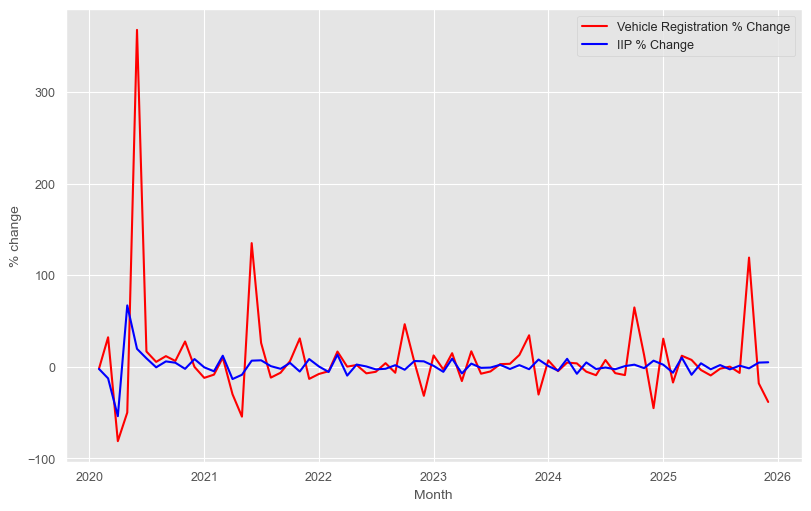

In [66]:
################################################## Fig. 7.2 ###################################################
import pandas as pd
import matplotlib.pyplot as plt

filepath =  data_dir / "india_change.xlsx"
df = pd.read_excel(filepath, parse_dates=["ds"] )
print(df.head())
fig, ax = plt.subplots()

# vehicle registration change
ax.plot(df["ds"], df["change_veh_reg"], label="Vehicle Registration % Change", color ="red")
ax.plot(df["ds"], df["change_in_iip"], label="IIP % Change", color ="blue")

ax.set_xlabel("Month")
ax.set_ylabel("% change")

ax.legend()
fig.savefig(fig_dir / "fig_07_02.png", dpi=300, bbox_inches="tight")
plt.show()



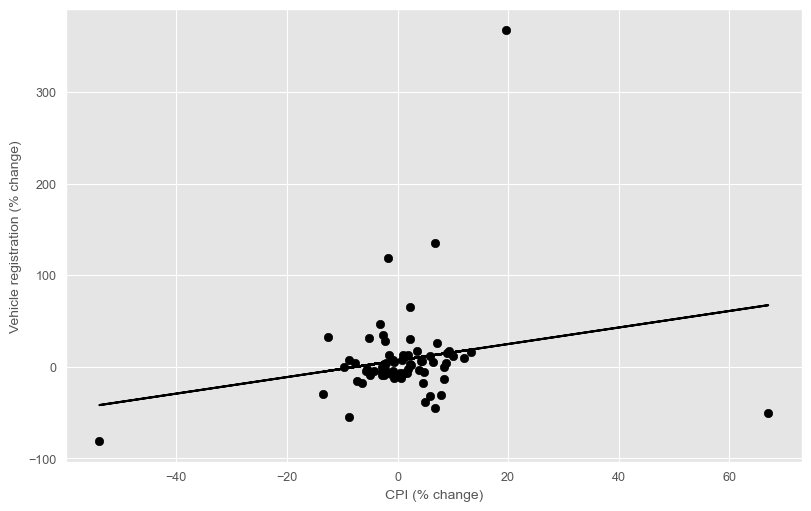

In [72]:
################################################## Fig. 7.3 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

# Load data
filepath =  data_dir / "india_change.xlsx"
india_change = pd.read_excel(filepath,
    parse_dates=["ds"]
)

india_change["ds"] = pd.to_datetime(india_change["ds"], dayfirst=True)
india_change["unique_id"] = "India"

# Fit regression (Fig 7.3 style)
mf = MLForecast(models=LinearRegression(), freq="MS")  # monthly frequency

mf.fit(
    india_change.rename(columns={"change_veh_reg":"y"})[
        ["ds","y","unique_id","change_in_iip"]
    ],
    fitted=True,
    static_features=[]
)

# Plot
fig, ax = plt.subplots()

ax.scatter(india_change["change_in_iip"],
           india_change["change_veh_reg"], color="k")

ax.plot(india_change["change_in_iip"],
        mf.forecast_fitted_values()["LinearRegression"])

ax.set(
    xlabel="IIP (% change)",
    ylabel="Vehicle registration (% change)"
)
fig.savefig(fig_dir / "fig_07_03.png", dpi=300, bbox_inches="tight")
plt.show()



In [96]:
#print(mf.models_["LinearRegression"].)
#print_regression_summary_from_model(mf.models_["LinearRegression"])


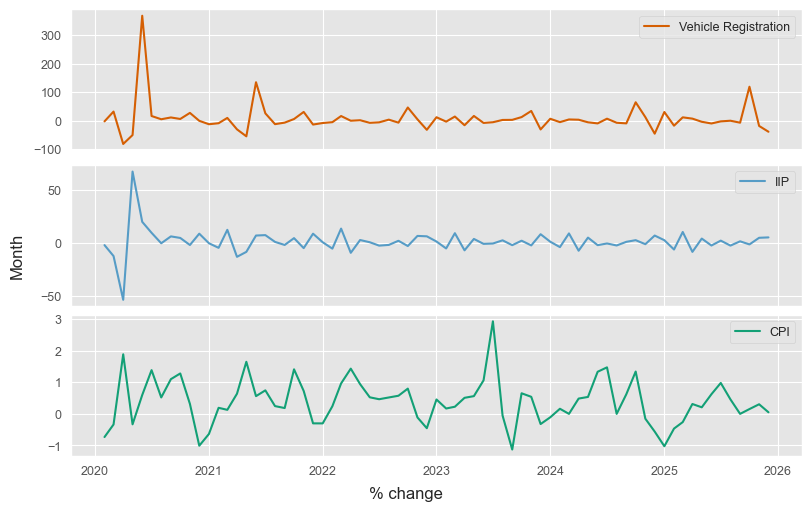

In [19]:
################################################## Fig. 7.4 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
filepath =  data_dir / "india_change.xlsx"

india_change = pd.read_excel(filepath,
    parse_dates=["ds"]
)

india_change["ds"] = pd.to_datetime(india_change["ds"], dayfirst=True)

# 3-panel plot
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True)

sns.lineplot(
    data=india_change, x="ds", y="change_veh_reg",
    ax=axes[0], color="#D55F03", label="Vehicle Registration"
)

sns.lineplot(
    data=india_change, x="ds", y="change_in_iip",
    ax=axes[1], color="#569CC6", label="IIP"
)

sns.lineplot(
    data=india_change, x="ds", y="change_in_cpi",
    ax=axes[2], color="#13A076", label="CPI"
)

# Remove axis labels
for ax in axes:
    ax.set(xlabel="", ylabel="")

# Shared labels
fig.supxlabel("% change")
fig.supylabel("Month")

fig.savefig(fig_dir / "fig_07_04.png", dpi=300, bbox_inches="tight")
plt.show()




/Users/satyendragupta/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


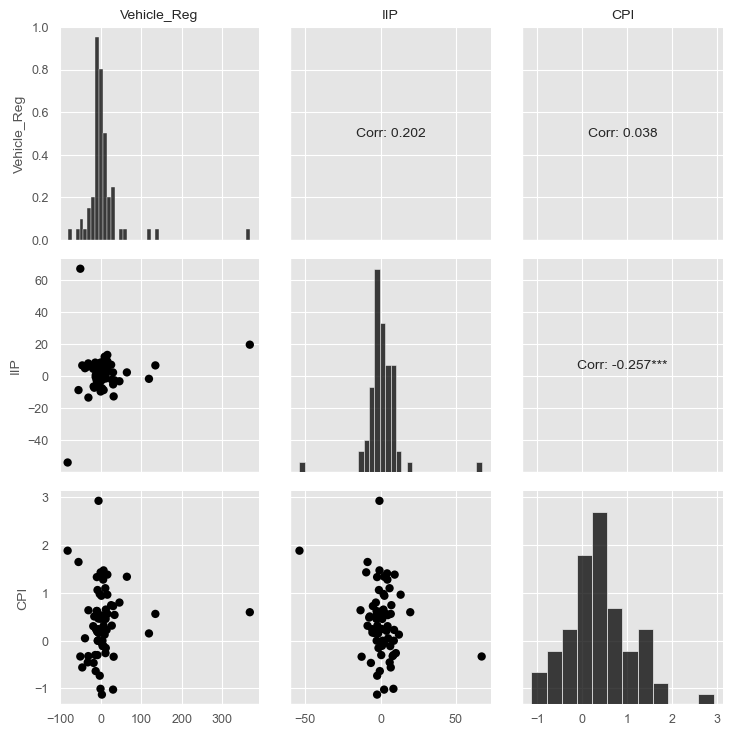

In [102]:
################################################## Fig. 7.5 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Load data
filepath =  data_dir / "india_change.xlsx"

india_change = pd.read_excel(filepath,
    parse_dates=["ds"]
)

# Select columns
columns = ["change_veh_reg", "change_in_iip", "change_in_cpi"]
df = india_change[columns].rename(columns={
    "change_veh_reg": "Vehicle_Reg",
    "change_in_iip": "IIP",
    "change_in_cpi": "CPI"
})

# Correlation annotation function
def corrfunc(x, y, **kws):
    r, pvalue = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(
        f"Corr: {r:.3f}{'***' if pvalue < 0.05 else ''}",
        xy=(0.5, 0.5), xycoords="axes fraction",
        ha="center", va="center"
    )

# PairGrid
g = sns.PairGrid(df)

g.map_diag(sns.histplot)
g.map_upper(corrfunc)
g.map_lower(sns.scatterplot, edgecolor="none")

# Titles on top
g.set(xlabel="")
for i, col in enumerate(df.columns):
    g.axes[0, i].set_title(col, size='medium')

plt.savefig(fig_dir / "fig_07_05.png", dpi=300, bbox_inches="tight")
plt.show()


In [25]:
import pandas as pd
import statsmodels.api as sm

# =====================
# Load data
# =====================
filepath =  data_dir / "india_change.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)

# =====================
# Regression variables
# =====================
y = df["change_veh_reg"]
X = df[["change_in_iip", "change_in_cpi"]]

# Add intercept
X = sm.add_constant(X)

# =====================
# Fit OLS
# =====================
model = sm.OLS(y, X).fit()

# =====================
# Print FPP-style summary
# =====================
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         change_veh_reg   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     1.767
Date:                Sun, 08 Feb 2026   Prob (F-statistic):              0.179
Time:                        12:20:06   Log-Likelihood:                -380.66
No. Observations:                  71   AIC:                             767.3
Df Residuals:                      68   BIC:                             774.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.9037      7.291      0.535

/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/2915046591.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


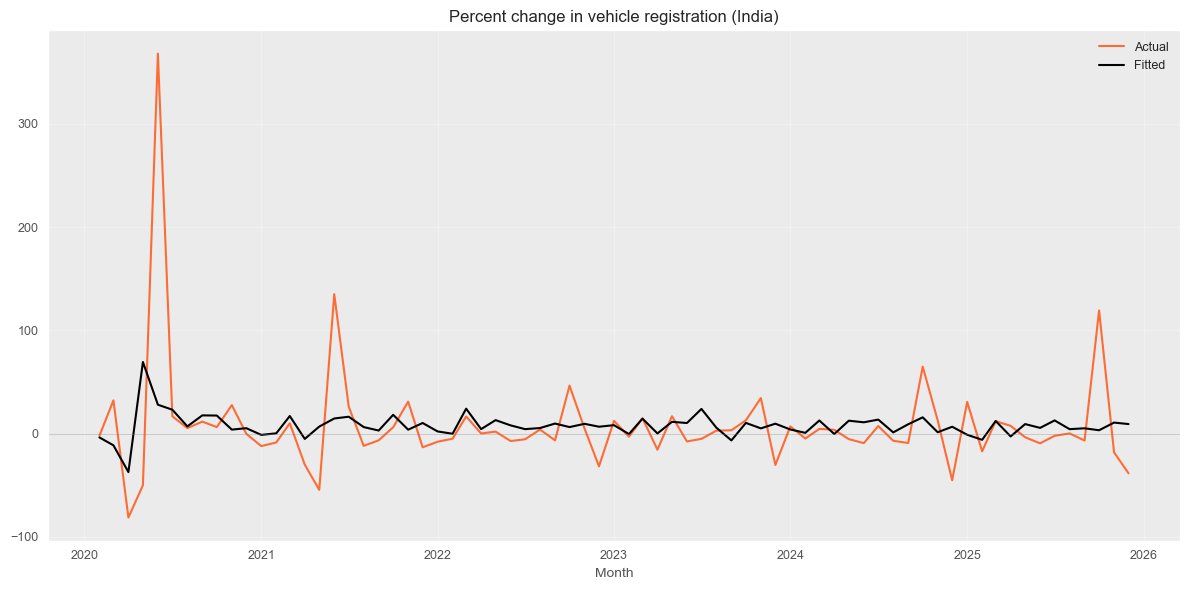

In [104]:
################################################## Fig. 7.6 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Read and prepare data
filepath =  data_dir / "india_change.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df['ds'] = pd.to_datetime(df['ds'], format='%d-%m-%Y')
df = df.sort_values('ds').reset_index(drop=True)

# Create dataframe with actual and fitted values
model = LinearRegression()
X = df[['change_in_iip', 'change_in_cpi']].values
model.fit(X, df['change_veh_reg'])

# Create fitted values dataframe (equivalent to their df)
fitted_df = pd.DataFrame({
    'ds': df['ds'],
    'fitted': model.predict(X)
})

# Plot (equivalent to their plot_series)
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['change_veh_reg'], color='#FF6B35', linewidth=1.5, label='Actual')
plt.plot(fitted_df['ds'], fitted_df['fitted'], color='#000000', linewidth=1.5, label='Fitted')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
plt.xlabel('Month')
plt.title('Percent change in vehicle registration (India)')
plt.legend(loc='upper right', frameon=False)
plt.gca().set_facecolor('#EBEBEB')
plt.grid(True, alpha=0.3, color='white')
plt.tight_layout()

plt.savefig(fig_dir / "fig_07_06.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1964012901.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


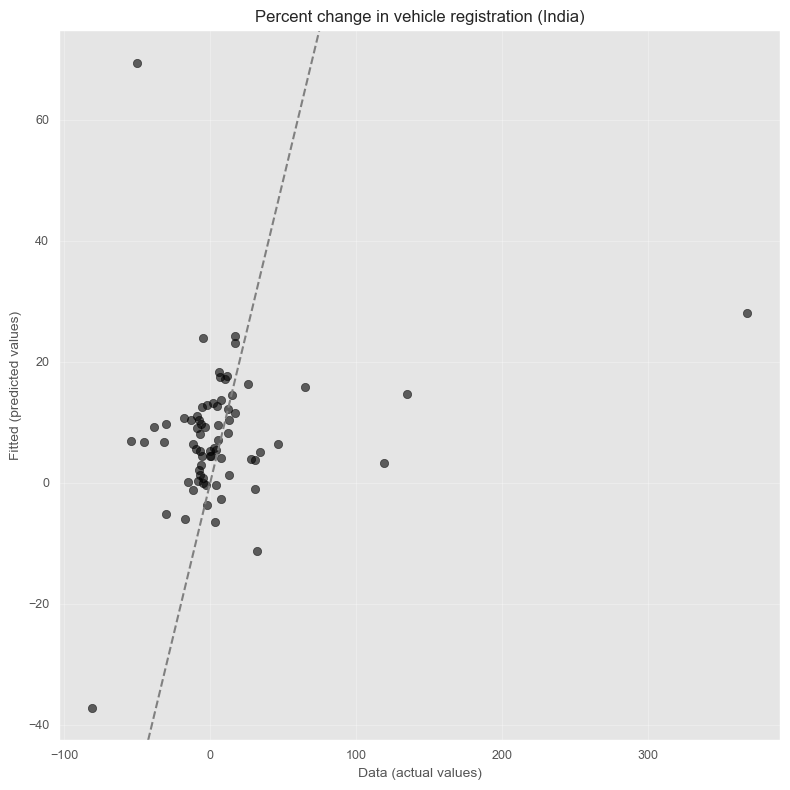

In [29]:
################################################## Fig. 7.7 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =====================
# 1. Load and prepare data
# =====================
filepath =  data_dir / "india_change.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)
df = df.sort_values("ds").reset_index(drop=True)

# =====================
# 2. Fit regression model
# =====================
X = df[["change_in_iip", "change_in_cpi"]]
y = df["change_veh_reg"]

model = LinearRegression()
model.fit(X, y)

fitted = model.predict(X)

# =====================
# 3. Fig 7.7: Actual vs fitted
# =====================
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y, fitted, color="black", alpha=0.6)
ax.axline((0, 0), slope=1, linestyle="--", color="gray")

ax.set(
    title="Percent change in vehicle registration (India)",
    xlabel="Data (actual values)",
    ylabel="Fitted (predicted values)"
)

ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig(fig_dir / "fig_07_07.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/3167415872.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


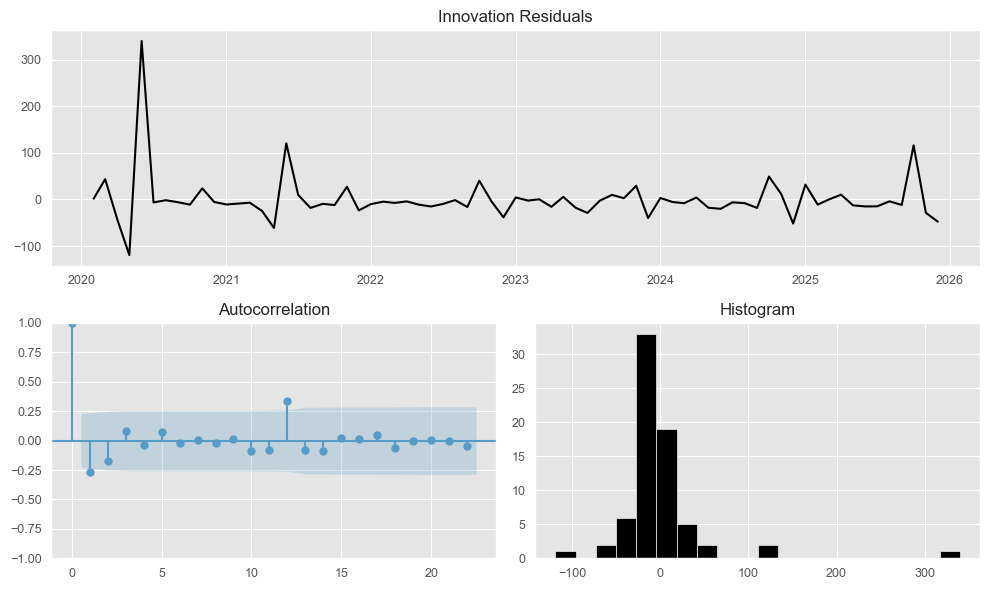

In [31]:
################################################## Fig. 7.8 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

# =====================
# Load data
# =====================
filepath =  data_dir / "india_change.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)
df = df.sort_values("ds")

# =====================
# Fit regression (same model)
# =====================
y = df["change_veh_reg"]
X = df[["change_in_iip","change_in_cpi"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

# Residuals
resid = model.resid

# =====================
# Diagnostic plots (Fig 7.8 style)
# =====================
fig = plt.figure(figsize=(10,6))

# Residual time plot
ax1 = plt.subplot(2,2,(1,2))
ax1.plot(df["ds"], resid, color="black")
ax1.set_title("Innovation Residuals")

# ACF plot
ax2 = plt.subplot(2,2,3)
plot_acf(resid, ax=ax2, lags=22)

# Histogram
ax3 = plt.subplot(2,2,4)
ax3.hist(resid, bins=20, color="black")
ax3.set_title("Histogram")

plt.tight_layout()

fig.savefig(fig_dir / "fig_07_08.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/977384044.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


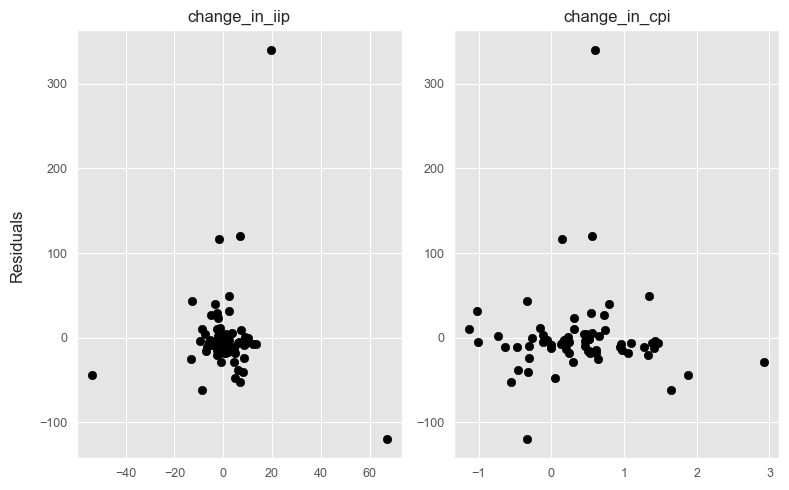

In [33]:
################################################## Fig. 7.9 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load data
filepath =  data_dir / "india_change.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)

# Fit regression
y = df["change_veh_reg"]
X = df[["change_in_iip","change_in_cpi"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
residuals = model.resid

# =====================
# Residual vs regressors (Fig style)
# =====================
fig, axes = plt.subplots(nrows=1, ncols=2)

columns = ["change_in_iip", "change_in_cpi"]

for ax, column in zip(axes.ravel(), columns):
    ax.scatter(df[column], residuals, color="black")
    ax.set(title=column)

fig.supylabel("Residuals")

plt.tight_layout()

fig.savefig(fig_dir / "fig_07_09.png", dpi=300, bbox_inches="tight")
plt.show()


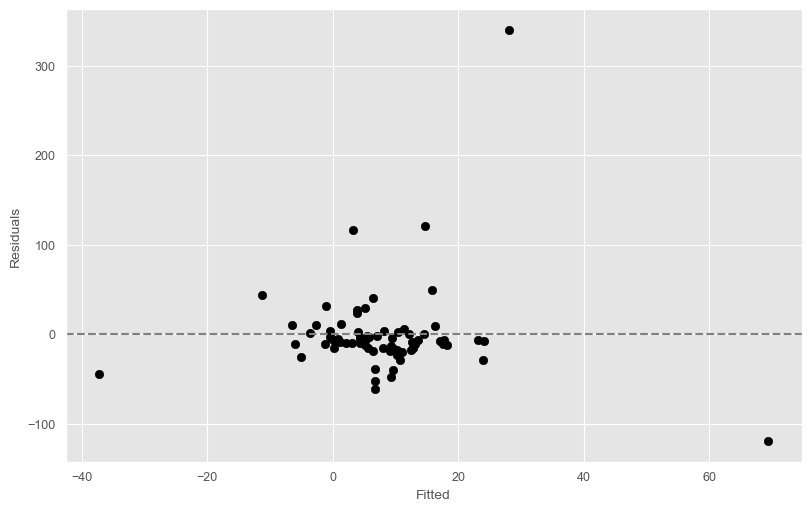

In [35]:
################################################## Fig. 7.10 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load data
filepath =  data_dir / "india_change.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)

# Fit regression
y = df["change_veh_reg"]
X = df[["change_in_iip","change_in_cpi"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

# Extract fitted values + residuals
insample_forecasts = model.fittedvalues
residuals = model.resid

# =====================
# Residual vs fitted plot
# =====================
fig, ax = plt.subplots()

ax.scatter(insample_forecasts, residuals, color="black")
ax.axhline(0, linestyle="--", color="gray")

ax.set(
    xlabel="Fitted",
    ylabel="Residuals"
)

fig.savefig(fig_dir / "fig_07_10.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1408335405.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


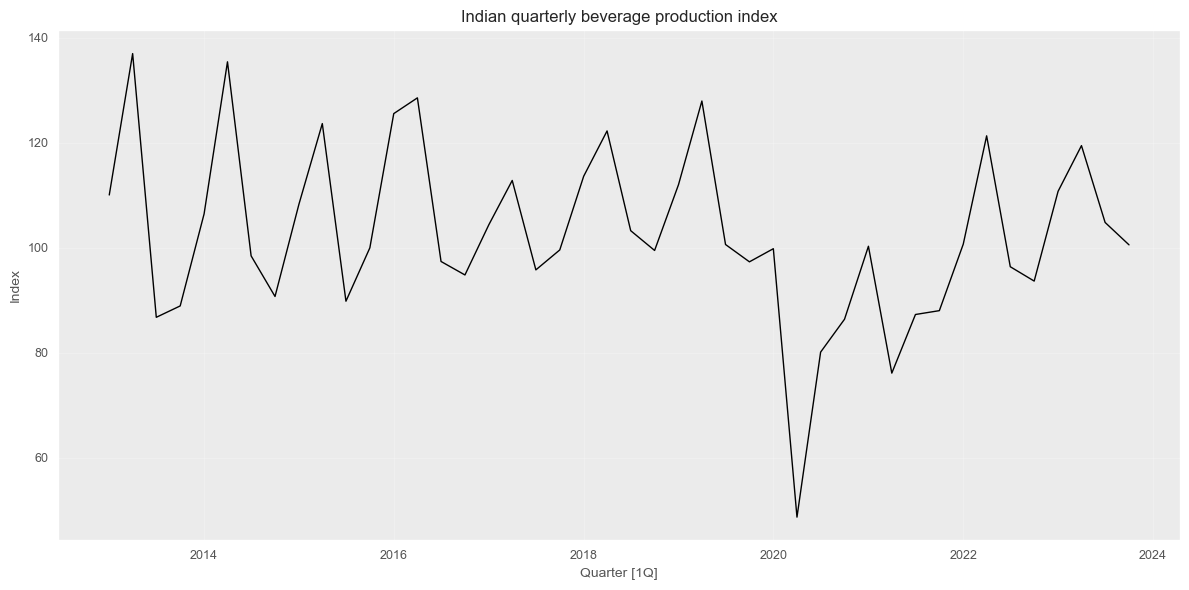

In [37]:
################################################## Fig. 7.14 ###################################################
import pandas as pd
import matplotlib.pyplot as plt

# Read data
filepath =  data_dir / "india_quart_bevg_prod_index_2013_2023.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df['ds'] = pd.to_datetime(df['ds'])

# Filter recent data (from 2013 onwards)
recent_bevg = df[df['ds'] >= '2013']

# Plot
plt.figure(figsize=(12, 6))
plt.plot(recent_bevg['ds'], recent_bevg['beverage_prod_index'], color='black', linewidth=1)
plt.xlabel('Quarter [1Q]')
plt.ylabel('Index')
plt.title('Indian quarterly beverage production index')
plt.gca().set_facecolor('#EBEBEB')
plt.grid(True, alpha=0.3, color='white', linewidth=0.5)
plt.tight_layout()

fig.savefig(fig_dir / "fig_07_14.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
############################################# setting up the model ######################################
import pandas as pd
import numpy as np
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression

# Read data
filepath =  data_dir / "india_quart_bevg_prod_index_2013_2023.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df['ds'] = pd.to_datetime(df['ds'])
recent_bevg = df[df['ds'] >= '2013'].copy()

# Prepare data
fit_bevg = recent_bevg.rename(columns={'beverage_prod_index': 'y'})
fit_bevg['trend'] = np.arange(1, len(fit_bevg) + 1)
quarter = pd.get_dummies(fit_bevg.ds.dt.quarter, prefix="Quarter", drop_first=True)
fit_bevg = fit_bevg.join(quarter)
fit_bevg['unique_id'] = 'Beverage'

# Fit model
mf = MLForecast(models=LinearRegression(), freq="QS-JAN")
mf.fit(fit_bevg, fitted=True, static_features=[])
insample = mf.forecast_fitted_values()

print(fit_bevg.head())

          ds        y  trend  Quarter_2  Quarter_3  Quarter_4 unique_id
0 2013-01-01  110.033      1      False      False      False  Beverage
1 2013-04-01  136.967      2       True      False      False  Beverage
2 2013-07-01   86.733      3      False       True      False  Beverage
3 2013-10-01   88.900      4      False      False       True  Beverage
4 2014-01-01  106.433      5      False      False      False  Beverage


/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/2137615870.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


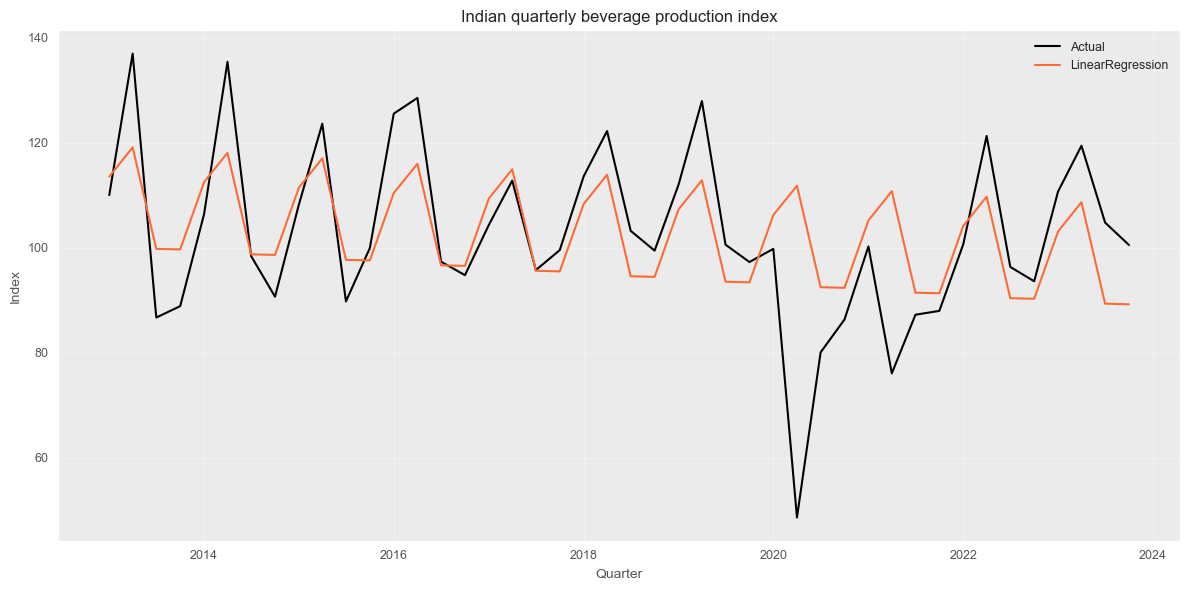

In [41]:
################################################## Fig. 7.15 ###################################################
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actual (black) and fitted (orange)
ax.plot(fit_bevg['ds'], fit_bevg['y'], color='black', linewidth=1.5, label='Actual')
ax.plot(fit_bevg['ds'], insample['LinearRegression'], color='#FF6B35', linewidth=1.5, label='LinearRegression')

# Styling
ax.set_xlabel('Quarter')
ax.set_ylabel('Index')
ax.set_title('Indian quarterly beverage production index')
ax.legend(loc='upper right', frameon=False)
ax.set_facecolor('#EBEBEB')
ax.grid(True, alpha=0.3, color='white')

plt.tight_layout()

fig.savefig(fig_dir / "fig_07_15.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/2385623857.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


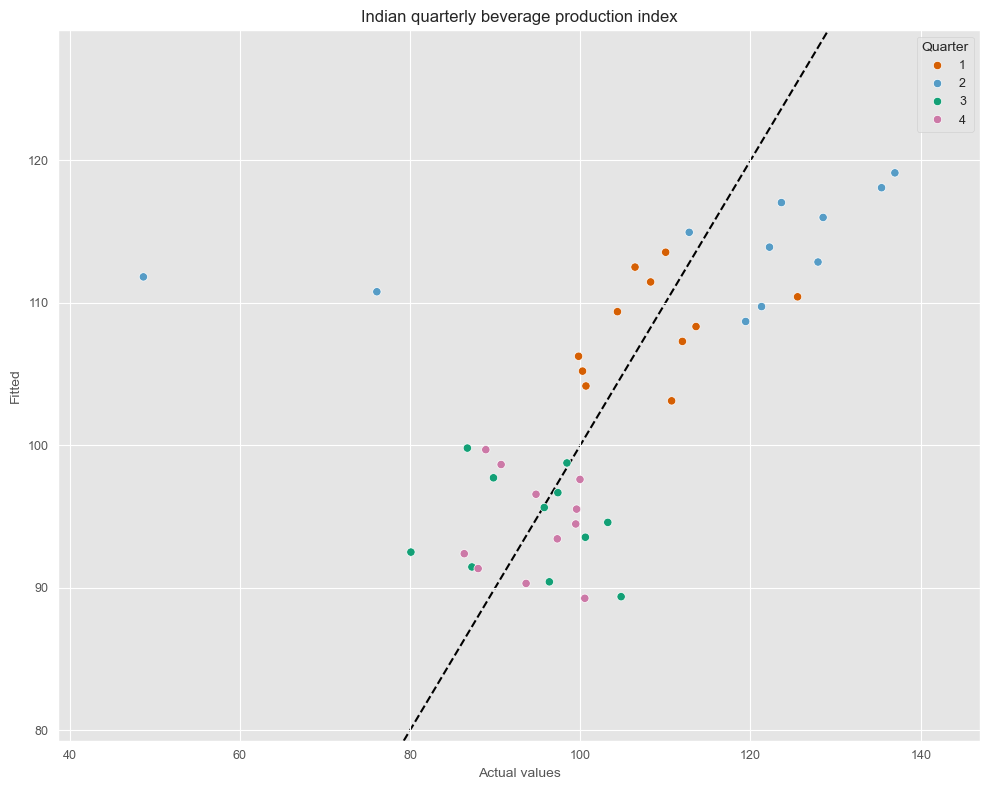

In [43]:
################################################## Fig. 7.16 ###################################################
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
fig, ax = plt.subplots(figsize=(10, 8))
df = insample.assign(Quarter=lambda x: x["ds"].dt.quarter)

# Scatter plot with quarter colors
sns.scatterplot(data=df, x="y", y="LinearRegression", 
                hue="Quarter", palette="r_colors", ax=ax)

# Add 45-degree line
ax.axline((0, 0), slope=1, linestyle="--", color="black", zorder=-1)

# Set labels and title
ax.set(
    xlim=(df['y'].min()-10, df['y'].max()+10), 
    ylim=(df['LinearRegression'].min()-10, df['LinearRegression'].max()+10),
    xlabel="Actual values", 
    ylabel="Fitted",
    title="Indian quarterly beverage production index"
)

plt.tight_layout()

fig.savefig(fig_dir / "fig_07_16.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1136011395.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


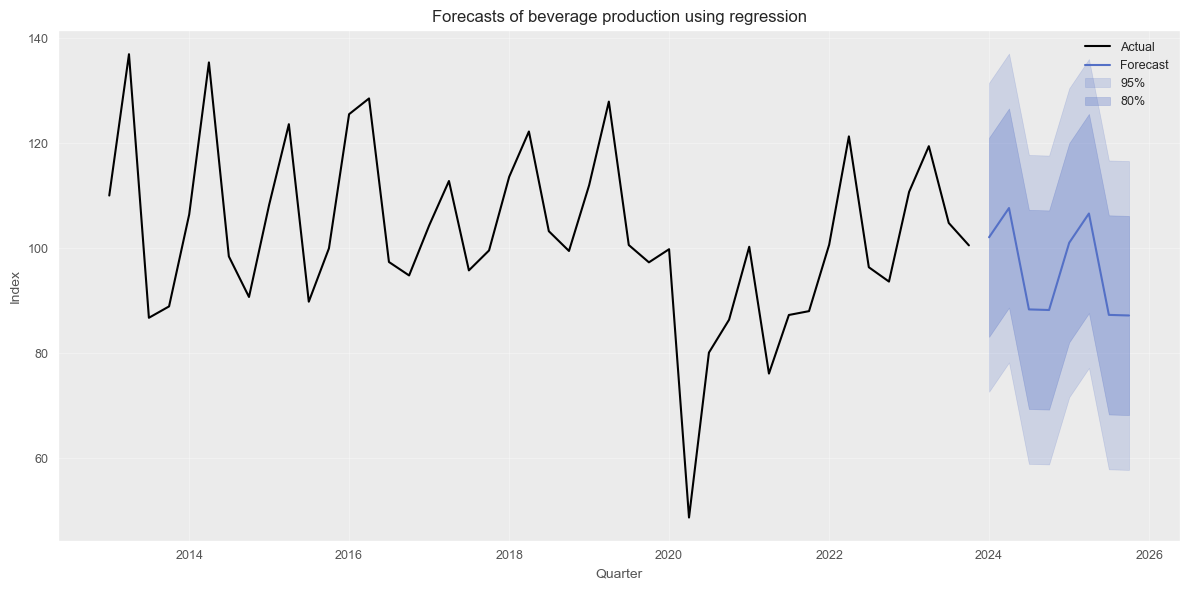

In [45]:
################################################## Fig. 7.17 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats
import numpy as np

# Load data
filepath =  data_dir / "india_quart_bevg_prod_index_2013_2023.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df['ds'] = pd.to_datetime(df['ds'])
beverage = df[df['ds'] >= '2013'][["ds", "beverage_prod_index"]].copy()
beverage = beverage.rename(columns={'beverage_prod_index': 'y'})
beverage["trend"] = range(len(beverage))

# Add quarter dummies (simpler approach)
beverage['quarter'] = beverage['ds'].dt.quarter
quarter_dummies = pd.get_dummies(beverage['quarter'], prefix='Q', drop_first=True)
beverage = pd.concat([beverage, quarter_dummies], axis=1)

# Train model
X = beverage[['trend', 'Q_2', 'Q_3', 'Q_4']]
model = LinearRegression().fit(X, beverage["y"])

# Future predictors
h = 8
future_trend = np.arange(len(beverage), len(beverage) + h)
future_dates = pd.date_range(start=beverage["ds"].max() + pd.DateOffset(months=3), periods=h, freq='QS-JAN')
future_quarters = [d.quarter for d in future_dates]
future_dummies = pd.get_dummies(future_quarters, drop_first=True, prefix='Q').reindex(columns=['Q_2', 'Q_3', 'Q_4'], fill_value=0)
X_future = pd.DataFrame({'trend': future_trend})
X_future = pd.concat([X_future, future_dummies.reset_index(drop=True)], axis=1)
y_pred = model.predict(X_future)

# Prediction intervals
residuals = beverage["y"] - model.predict(X)
se = np.sqrt(np.sum(residuals**2) / (len(beverage) - 4))
se_pred = se * np.sqrt(1 + 1/len(beverage))
lower_80 = y_pred - stats.t.ppf(0.90, len(beverage)-4) * se_pred
upper_80 = y_pred + stats.t.ppf(0.90, len(beverage)-4) * se_pred
lower_95 = y_pred - stats.t.ppf(0.975, len(beverage)-4) * se_pred
upper_95 = y_pred + stats.t.ppf(0.975, len(beverage)-4) * se_pred

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(beverage["ds"], beverage["y"], 'k-', linewidth=1.5, label='Actual')
ax.plot(future_dates, y_pred, color='#5470C6', linewidth=1.5, label='Forecast')
ax.fill_between(future_dates, lower_95, upper_95, alpha=0.2, color='#5470C6', label='95%')
ax.fill_between(future_dates, lower_80, upper_80, alpha=0.3, color='#5470C6', label='80%')
ax.set_xlabel('Quarter')
ax.set_ylabel('Index')
ax.set_title('Forecasts of beverage production using regression')
ax.legend(loc='upper right', frameon=False)
ax.set_facecolor('#EBEBEB')
ax.grid(True, alpha=0.3, color='white')
plt.tight_layout()

fig.savefig(fig_dir / "fig_07_17.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/satyendragupta/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/3262869815.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


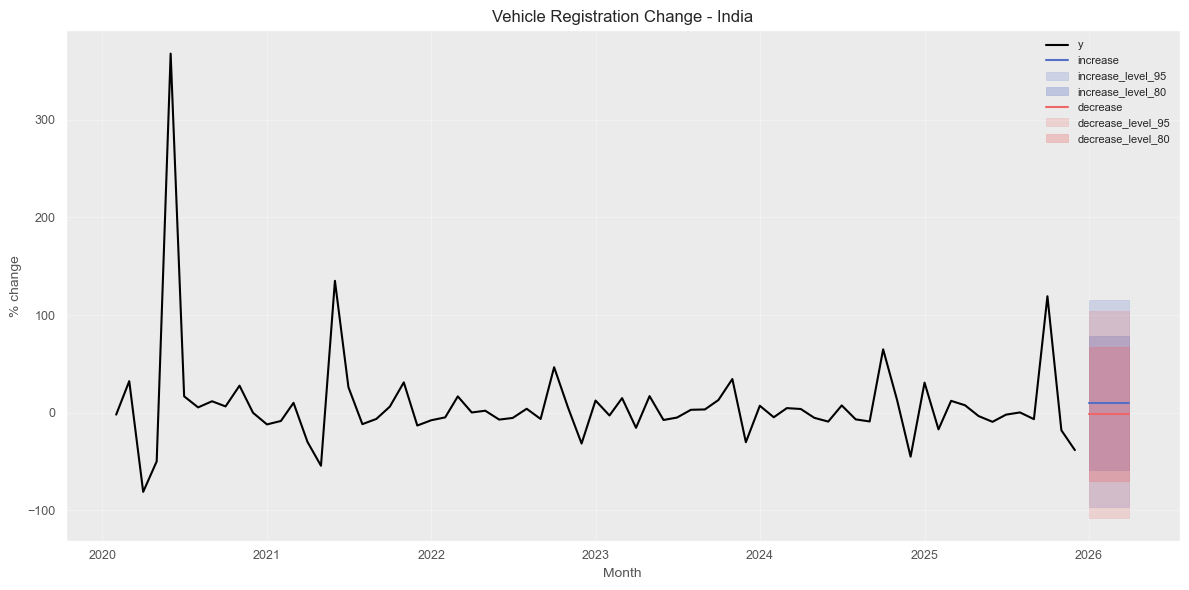

In [47]:
################################################## Fig. 7.18 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast
from scipy import stats
import numpy as np

# Load and prepare data
filepath =  data_dir / "india_change.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)

df['ds'] = pd.to_datetime(df['ds'], format='%d-%m-%Y')
india_change = df.rename(columns={'change_veh_reg': 'y'})
india_change['unique_id'] = 'India'

# Fit model
mf = MLForecast(models=LinearRegression(), freq="MS")
mf.fit(india_change[['unique_id', 'ds', 'y', 'change_in_iip', 'change_in_cpi']], static_features=[])
futr_base = mf.make_future_dataframe(h=4)

# Get model for prediction intervals
X_train = india_change[['change_in_iip', 'change_in_cpi']].values
y_train = india_change['y'].values
residuals = y_train - mf.models_['LinearRegression'].predict(X_train)
se = np.sqrt(np.sum(residuals**2) / (len(y_train) - 3))

# Function to create forecasts with intervals
def scenario_forecast(futr_df, name):
    fcst = mf.predict(h=4, X_df=futr_df)
    se_pred = se * np.sqrt(1 + 1/len(y_train))
    fcst[f'{name}_lo_80'] = fcst['LinearRegression'] - stats.t.ppf(0.90, len(y_train)-3) * se_pred
    fcst[f'{name}_hi_80'] = fcst['LinearRegression'] + stats.t.ppf(0.90, len(y_train)-3) * se_pred
    fcst[f'{name}_lo_95'] = fcst['LinearRegression'] - stats.t.ppf(0.975, len(y_train)-3) * se_pred
    fcst[f'{name}_hi_95'] = fcst['LinearRegression'] + stats.t.ppf(0.975, len(y_train)-3) * se_pred
    fcst[name] = fcst['LinearRegression']
    return fcst

# Scenarios
fcst1 = scenario_forecast(futr_base.assign(change_in_iip=2, change_in_cpi=0.5), 'increase')
fcst2 = scenario_forecast(futr_base.assign(change_in_iip=-2, change_in_cpi=-0.5), 'decrease')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(india_change['ds'], india_change['y'], 'k-', linewidth=1.5, label='y')
ax.plot(fcst1['ds'], fcst1['increase'], color='#5470C6', linewidth=1.5, label='increase')
ax.fill_between(fcst1['ds'], fcst1['increase_lo_95'], fcst1['increase_hi_95'], alpha=0.2, color='#5470C6', label='increase_level_95')
ax.fill_between(fcst1['ds'], fcst1['increase_lo_80'], fcst1['increase_hi_80'], alpha=0.3, color='#5470C6', label='increase_level_80')
ax.plot(fcst2['ds'], fcst2['decrease'], color='#EE6666', linewidth=1.5, label='decrease')
ax.fill_between(fcst2['ds'], fcst2['decrease_lo_95'], fcst2['decrease_hi_95'], alpha=0.2, color='#EE6666', label='decrease_level_95')
ax.fill_between(fcst2['ds'], fcst2['decrease_lo_80'], fcst2['decrease_hi_80'], alpha=0.3, color='#EE6666', label='decrease_level_80')
ax.set_xlabel('Month')
ax.set_ylabel('% change')
ax.set_title('Vehicle Registration Change - India')
ax.legend(loc='upper right', frameon=False, fontsize=8)
ax.set_facecolor('#EBEBEB')
ax.grid(True, alpha=0.3, color='white')
plt.tight_layout()

fig.savefig(fig_dir / "fig_07_18.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/satyendragupta/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_22182/1030730614.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


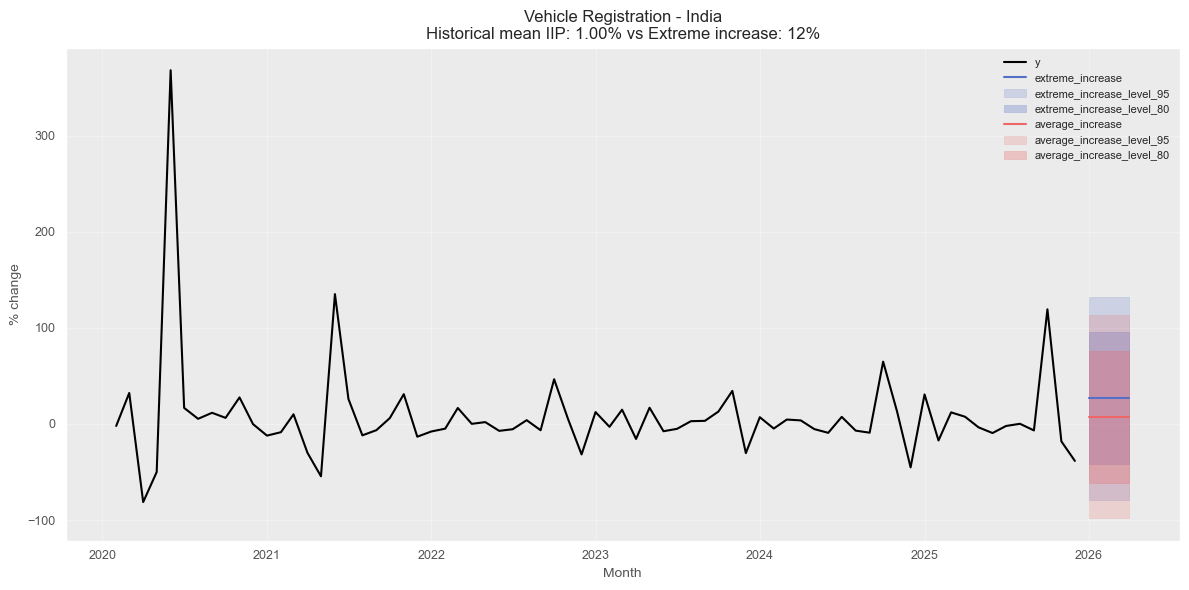

In [49]:
################################################## Fig. 7.18 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast
from scipy import stats
import numpy as np

# Load and prepare data
filepath =  data_dir / "india_change.xlsx"

df = pd.read_excel(filepath,
    parse_dates=["ds"]
)
df['ds'] = pd.to_datetime(df['ds'], format='%d-%m-%Y')
india_change = df.rename(columns={'change_veh_reg': 'y'})
india_change['unique_id'] = 'India'

# Calculate historical means
mean_iip = india_change['change_in_iip'].mean()
mean_cpi = india_change['change_in_cpi'].mean()

# Fit model
mf = MLForecast(models=LinearRegression(), freq="MS")
mf.fit(india_change[['unique_id', 'ds', 'y', 'change_in_iip', 'change_in_cpi']], static_features=[])
futr_base = mf.make_future_dataframe(h=4)

# Calculate prediction intervals
X_train = india_change[['change_in_iip', 'change_in_cpi']].values
y_train = india_change['y'].values
residuals = y_train - mf.models_['LinearRegression'].predict(X_train)
se = np.sqrt(np.sum(residuals**2) / (len(y_train) - 3))

def scenario_forecast(futr_df, name):
    fcst = mf.predict(h=4, X_df=futr_df)
    se_pred = se * np.sqrt(1 + 1/len(y_train))
    fcst[f'{name}_lo_80'] = fcst['LinearRegression'] - stats.t.ppf(0.90, len(y_train)-3) * se_pred
    fcst[f'{name}_hi_80'] = fcst['LinearRegression'] + stats.t.ppf(0.90, len(y_train)-3) * se_pred
    fcst[f'{name}_lo_95'] = fcst['LinearRegression'] - stats.t.ppf(0.975, len(y_train)-3) * se_pred
    fcst[f'{name}_hi_95'] = fcst['LinearRegression'] + stats.t.ppf(0.975, len(y_train)-3) * se_pred
    fcst[name] = fcst['LinearRegression']
    return fcst

# Scenarios
fcst_extreme = scenario_forecast(futr_base.assign(change_in_iip=12, change_in_cpi=1.5), 'extreme_increase')
fcst_average = scenario_forecast(futr_base.assign(change_in_iip=mean_iip, change_in_cpi=mean_cpi), 'average_increase')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(india_change['ds'], india_change['y'], 'k-', linewidth=1.5, label='y')
ax.plot(fcst_extreme['ds'], fcst_extreme['extreme_increase'], color='#5470C6', linewidth=1.5, label='extreme_increase')
ax.fill_between(fcst_extreme['ds'], fcst_extreme['extreme_increase_lo_95'], fcst_extreme['extreme_increase_hi_95'], 
                alpha=0.2, color='#5470C6', label='extreme_increase_level_95')
ax.fill_between(fcst_extreme['ds'], fcst_extreme['extreme_increase_lo_80'], fcst_extreme['extreme_increase_hi_80'], 
                alpha=0.3, color='#5470C6', label='extreme_increase_level_80')
ax.plot(fcst_average['ds'], fcst_average['average_increase'], color='#EE6666', linewidth=1.5, label='average_increase')
ax.fill_between(fcst_average['ds'], fcst_average['average_increase_lo_95'], fcst_average['average_increase_hi_95'], 
                alpha=0.2, color='#EE6666', label='average_increase_level_95')
ax.fill_between(fcst_average['ds'], fcst_average['average_increase_lo_80'], fcst_average['average_increase_hi_80'], 
                alpha=0.3, color='#EE6666', label='average_increase_level_80')
ax.set_xlabel('Month')
ax.set_ylabel('% change')
ax.set_title(f'Vehicle Registration - India\nHistorical mean IIP: {mean_iip:.2f}% vs Extreme increase: 12%')
ax.legend(loc='upper right', frameon=False, fontsize=8)
ax.set_facecolor('#EBEBEB')
ax.grid(True, alpha=0.3, color='white')
plt.tight_layout()
plt.show()
